# Chương 2 - Phần 2 - III. Câu hỏi mở rộng

> Notebook độc lập, có thể chạy từ đầu bằng Restart Kernel and Run All.


## Chuẩn bị thư viện và dữ liệu ảnh

**Input:** môi trường Python và một ảnh bất kỳ.

**Output:** ảnh gốc, ảnh xám và các kết quả xử lý khác nhau để kiểm thử Canny.

**Thuật toán:** đọc ảnh có sẵn bằng OpenCV, chuyển sang ảnh xám rồi dùng các bước phát hiện cạnh để quan sát kết quả.

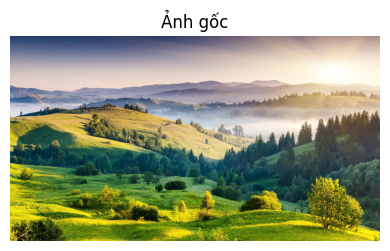

In [1]:
# !pip install opencv-python matplotlib numpy scikit-image
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage import feature, img_as_ubyte
from skimage.color import rgb2gray

IMAGE_PATH = 'image/sample_chapter_part_2.jpg'
OUTPUT_DIR = Path('outputs_chapter_2_part_2')
OUTPUT_DIR.mkdir(exist_ok=True)

image_bgr = cv2.imread(IMAGE_PATH)
if image_bgr is None:
    raise FileNotFoundError(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
gray_float = rgb2gray(image_rgb)

def show_images(items, cols=None):
    cols = cols or len(items)
    rows = (len(items) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)
    for ax, (title, img) in zip(axes.ravel(), items):
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(title)
        ax.axis('off')
    for ax in axes.ravel()[len(items):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_images([('Ảnh gốc', image_rgb)])


# III. Các câu hỏi mở rộng

## Câu III.1. Làm thế nào để đánh giá chất lượng cạnh phát hiện bởi Canny?

Có thể đánh giá bằng cách so sánh với ảnh biên chuẩn nếu có nhãn, dùng các độ đo precision, recall, F1-score. Nếu không có nhãn, có thể đánh giá trực quan theo các tiêu chí: cạnh có mảnh không, có bị đứt nhiều không, có nhiều cạnh giả do nhiễu không, các biên quan trọng của vật thể có được giữ không.

## Câu III.2. Phương pháp cải thiện hiệu suất Canny

- Tiền xử lý bằng Gaussian blur, median filter hoặc bilateral filter để giảm nhiễu.
- Chọn ngưỡng tự động bằng histogram hoặc Otsu thay vì đặt tay.
- Resize ảnh nếu ảnh quá lớn và không cần độ phân giải đầy đủ.
- Chỉ xử lý vùng quan tâm ROI thay vì toàn bộ ảnh.
- Với video, có thể xử lý cách frame hoặc dùng GPU nếu cần thời gian thực.

## Câu III.3. Canny có dùng cho ảnh màu không?

Canny trong OpenCV thường nhận ảnh xám. Với ảnh màu, cách phổ biến là chuyển RGB/BGR sang grayscale rồi chạy Canny. Nếu muốn tận dụng thông tin màu, có thể chạy Canny trên từng kênh màu hoặc trên các kênh trong HSV/LAB, sau đó kết hợp kết quả bằng phép OR.

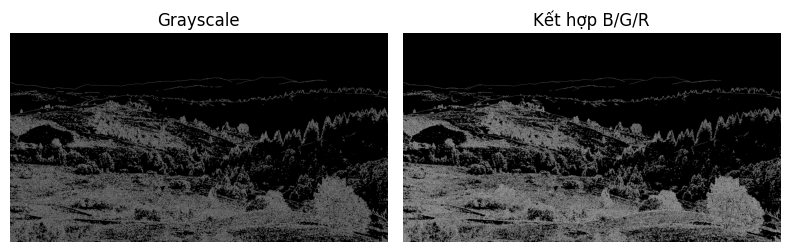

In [2]:
channel_edges = [cv2.Canny(channel, 80, 160) for channel in cv2.split(image_bgr)]
color_edges = cv2.bitwise_or(cv2.bitwise_or(channel_edges[0], channel_edges[1]), channel_edges[2])

cv2.imwrite(str(OUTPUT_DIR / 'III_3_canny_color_channels.png'), color_edges)
show_images([('Grayscale', cv2.Canny(gray, 80, 160)), ('Kết hợp B/G/R', color_edges)])


## Câu III.4. Áp dụng Canny cho video

Để áp dụng Canny cho video, đọc từng frame bằng `cv2.VideoCapture`, chuyển frame sang grayscale, làm mượt, chạy `cv2.Canny`, sau đó hiển thị hoặc ghi ra video mới bằng `cv2.VideoWriter`.

**Pseudocode:**

```python
cap = cv2.VideoCapture('input.mp4')
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 1.4)
    edges = cv2.Canny(gray, 80, 160)
    cv2.imshow('edges', edges)
cap.release()
cv2.destroyAllWindows()
```

Khi xử lý video cần chú ý tốc độ frame, kích thước ảnh và độ ổn định tham số giữa các frame.